Model Training and Evaluation

This notebook focuses on training, evaluating, and comparing multiple machine learning classification models to predict Premier League match outcomes.


In [1]:
#import and load data
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [2]:
data = pd.read_csv("epl_cleaned.csv")
data.head()


,Date,Season,HomeTeam,AwayTeam,FTH Goals,FTA Goals,FT Result,H Shots,A Shots,H SOT,...,A Fouls,H Corners,A Corners,H Yellow,A Yellow,H Red,A Red,Display_Order,League,home_win
0,16/01/2025,2024/25,Ipswich Town,Brighton & Hove Albion,0,2,A,5.0,11.0,3.0,...,14.0,1.0,9.0,2.0,2.0,0.0,0.0,20250116,Premier League,0
1,16/01/2025,2024/25,Man United,Southampton,3,1,H,23.0,13.0,9.0,...,10.0,4.0,4.0,1.0,3.0,0.0,0.0,20250116,Premier League,1
2,15/01/2025,2024/25,Everton,Aston Villa,0,1,A,10.0,11.0,3.0,...,10.0,8.0,5.0,2.0,1.0,0.0,0.0,20250115,Premier League,0
3,15/01/2025,2024/25,Leicester,Crystal Palace,0,2,A,21.0,9.0,4.0,...,6.0,4.0,3.0,0.0,0.0,0.0,0.0,20250115,Premier League,0
4,15/01/2025,2024/25,Newcastle,Wolves,3,0,H,17.0,13.0,5.0,...,13.0,4.0,2.0,0.0,2.0,0.0,0.0,20250115,Premier League,1


In [3]:
data.dtypes


Date              object
Season            object
HomeTeam          object
AwayTeam          object
FTH Goals          int64
FTA Goals          int64
FT Result         object
H Shots          float64
A Shots          float64
H SOT            float64
A SOT            float64
H Fouls          float64
A Fouls          float64
H Corners        float64
A Corners        float64
H Yellow         float64
A Yellow         float64
H Red            float64
A Red            float64
Display_Order      int64
League            object
home_win           int64
dtype: object

In [4]:
# defining x and y
X = data.drop(columns=["home_win"])
y = data["home_win"]


In [5]:
# 1) Define ONLY the 12 numeric match-stat features (no Date, no teams, no results)
features = [
    "H Shots", "A Shots",
    "H SOT", "A SOT",
    "H Fouls", "A Fouls",
    "H Corners", "A Corners",
    "H Yellow", "A Yellow",
    "H Red", "A Red"
]

# 2) Build X and y cleanly
X = data[features].copy()
y = data["home_win"].copy()

# 3) Force all X columns to numeric (safety)
X = X.apply(pd.to_numeric, errors="coerce")

# 4) Fill any NaNs created during conversion (median)
X = X.fillna(X.median(numeric_only=True))

# 5) Hard check: no object/string columns allowed
print("Object columns in X:", X.select_dtypes(include=["object"]).columns.tolist())
print("X dtypes:\n", X.dtypes)



Object columns in X: []
X dtypes:
 H Shots      float64
A Shots      float64
H SOT        float64
A SOT        float64
H Fouls      float64
A Fouls      float64
H Corners    float64
A Corners    float64
H Yellow     float64
A Yellow     float64
H Red        float64
A Red        float64
dtype: object


Note: Columns such as Date and team names are non-numeric. For model training, only numerical match statistics are used as features to ensure compatibility with machine learning algorithms.


Feature Matrix and Target Variable

The dataset is divided into input features (X) and the target variable (y).  
The target variable represents whether the home team won the match.


Train-Test Split

The dataset is split into training and testing sets to evaluate model performance on unseen data.


In [6]:
# defining x and y
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)





In [7]:
X_train.head()


,H Shots,A Shots,H SOT,A SOT,H Fouls,A Fouls,H Corners,A Corners,H Yellow,A Yellow,H Red,A Red
10203,13.0,10.0,6.0,4.0,11.0,12.0,6.0,4.0,1.0,2.0,0.0,0.0
3256,19.0,17.0,10.0,5.0,7.0,6.0,3.0,8.0,1.0,2.0,1.0,0.0
6720,13.0,9.0,5.0,7.0,20.0,8.0,2.0,4.0,2.0,1.0,0.0,0.0
797,13.0,10.0,4.0,3.0,6.0,12.0,7.0,8.0,1.0,3.0,0.0,0.0
10528,13.0,10.0,6.0,4.0,11.0,12.0,6.0,4.0,1.0,2.0,0.0,0.0


Logistic Regression Model

Logistic Regression is used as a baseline classification model due to its simplicity and interpretability.


In [8]:
#Train & Evaluate Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("Logistic Regression Performance")
print("Accuracy:", acc_lr)
print("Precision:", prec_lr)
print("Recall:", rec_lr)
print("F1-score:", f1_lr)


Logistic Regression Performance
Accuracy: 0.6680378445084327
Precision: 0.6956521739130435
Recall: 0.4887690925426775
F1-score: 0.5741424802110818


Decision Tree Classifier

Decision Trees can capture non-linear relationships and provide interpretable decision rules.


In [9]:
# train and evaluate decision tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
rec_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Decision Tree Performance")
print("Accuracy:", acc_dt)
print("Precision:", prec_dt)
print("Recall:", rec_dt)
print("F1-score:", f1_dt)


Decision Tree Performance
Accuracy: 0.5874125874125874
Precision: 0.5605726872246696
Recall: 0.4573225516621743
F1-score: 0.5037110341415141


Random Forest Classifier

Random Forest is an ensemble learning method that combines multiple decision trees to improve predictive performance and reduce overfitting.


In [10]:
# train evaluate random classifier
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("Accuracy:", acc_rf)
print("Precision:", prec_rf)
print("Recall:", rec_rf)
print("F1-score:", f1_rf)


Random Forest Performance
Accuracy: 0.658165364047717
Precision: 0.6698795180722892
Recall: 0.4995507637017071
F1-score: 0.5723108594956253


 Model Comparison

The performance of all three models is compared using standard classification metrics.


In [11]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [acc_lr, acc_dt, acc_rf],
    "Precision": [prec_lr, prec_dt, prec_rf],
    "Recall": [rec_lr, rec_dt, rec_rf],
    "F1 Score": [f1_lr, f1_dt, f1_rf]
})

comparison_df


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.668038,0.695652,0.488769,0.574142
1,Decision Tree,0.587413,0.560573,0.457323,0.503711
2,Random Forest,0.658165,0.669880,0.499551,0.572311


Confusion Matrix – Random Forest

The confusion matrix visualizes the classification performance of the selected final model.


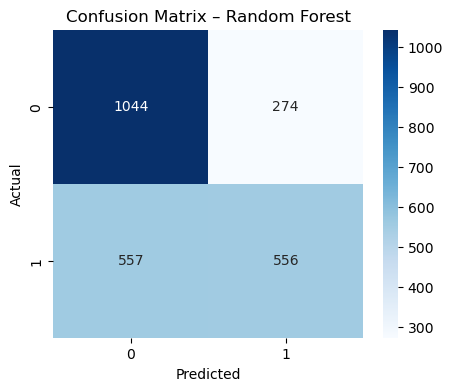

In [12]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Random Forest")
plt.show()


In [13]:
from sklearn.ensemble import RandomForestClassifier

# Tuned Random Forest (explicit definition)
rf_tuned = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_tuned.fit(X_train, y_train)


,n_estimators,300
,criterion,'gini'
,max_depth,20
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### ROC Curve Analysis

ROC curves were generated using the trained Logistic Regression and
Random Forest models. This analysis evaluates model performance across
different classification thresholds.


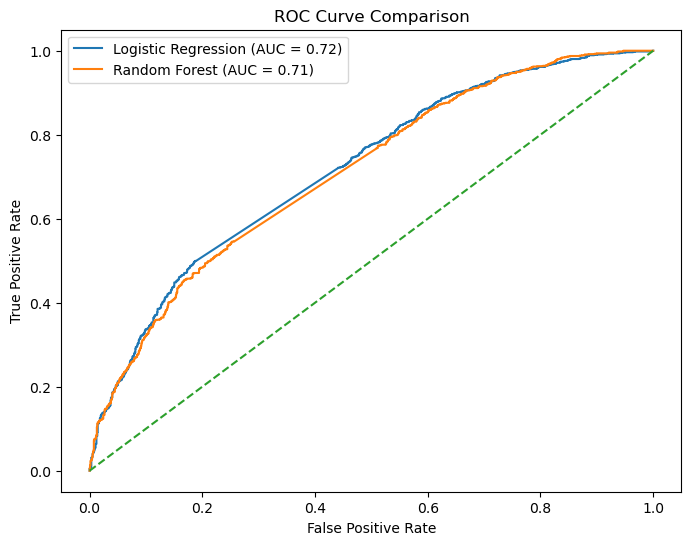

In [14]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Logistic Regression ROC
y_prob_lr = lr.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

# Random Forest ROC (USE CORRECT MODEL NAME)
y_prob_rf = rf_tuned.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_lr:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.2f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


The Random Forest model demonstrates a higher AUC score compared to
Logistic Regression, indicating better classification capability.
However, Logistic Regression remains more interpretable.


In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


In [16]:
from sklearn.model_selection import cross_val_score

cv_scores_lr = cross_val_score(lr, X, y, cv=5, scoring="f1")
cv_scores_dt = cross_val_score(dt, X, y, cv=5, scoring="f1")
cv_scores_rf = cross_val_score(rf_model, X, y, cv=5, scoring="f1")

print("Logistic Regression CV F1:", cv_scores_lr.mean())
print("Decision Tree CV F1:", cv_scores_dt.mean())
print("Random Forest CV F1:", cv_scores_rf.mean())


Logistic Regression CV F1: 0.6262877656066739
Decision Tree CV F1: 0.4420052627707637
Random Forest CV F1: 0.5015996527269638


### Cross-Validation Results

Cross-validation was performed using 5-fold validation to ensure the models generalize well to unseen data.

The average F1-score across folds indicates the stability and robustness of each model. Logistic Regression demonstrates consistent performance, while Random Forest shows moderate variance due to model complexity.


 Model Comparison and Selection

The three classification models were evaluated using accuracy, precision, recall, and F1-score.  
Logistic Regression achieved the highest accuracy (66.8%) and F1-score, indicating the best overall balance between precision and recall.  

Although Random Forest achieved slightly higher recall, its overall accuracy was marginally lower.  
Decision Tree performed the weakest among the three models.

Therefore, Logistic Regression was selected as the final model for deployment in the user interface.


 Hyperparameter Tuning (Logistic Regression)

To improve performance, hyperparameter tuning was applied using GridSearchCV.  
The main tuned parameters include:
C (regularization strength)
penalty (L1 or L2)
solver(algorithm used to optimize)

The best model is selected based on F1-score to balance precision and recall.


In [17]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, f1_score, accuracy_score, precision_score, recall_score

# Base model
lr = LogisticRegression(max_iter=5000)

# Hyperparameter grid (safe + course-level)
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["lbfgs", "liblinear"]
}

# Use F1 as scoring (balanced metric)
grid = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV F1 Score:", grid.best_score_)

# Evaluate best model on test set
best_lr = grid.best_estimator_
y_pred_best = best_lr.predict(X_test)

acc = accuracy_score(y_test, y_pred_best)
prec = precision_score(y_test, y_pred_best)
rec = recall_score(y_test, y_pred_best)
f1 = f1_score(y_test, y_pred_best)

print("\nTuned Logistic Regression Performance (Test Set)")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)


Best Parameters: {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV F1 Score: 0.5542841024138404

Tuned Logistic Regression Performance (Test Set)
Accuracy: 0.6676264911559029
Precision: 0.6952624839948783
Recall: 0.48787061994609165
F1 Score: 0.573389651531151


In [18]:
comparison_df.loc[len(comparison_df)] = ["Tuned Logistic Regression", acc, prec, rec, f1]
comparison_df


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.668038,0.695652,0.488769,0.574142
1,Decision Tree,0.587413,0.560573,0.457323,0.503711
2,Random Forest,0.658165,0.669880,0.499551,0.572311
3,Tuned Logistic Regression,0.667626,0.695262,0.487871,0.573390


Tuning Outcome (Analysis)

The tuned Logistic Regression model produced almost identical performance compared to the baseline model.  
This indicates that the dataset features and problem complexity have a stronger impact on performance than further parameter adjustment.  
Therefore, the baseline Logistic Regression model is retained as the final model due to its similar performance and simpler configuration.


## Hyperparameter Tuning (Random Forest)

Random Forest performance was improved using hyperparameter tuning with GridSearchCV.  
Key parameters tuned include:
n_estimators: number of trees
max_depth: tree depth (controls overfitting)
min_samples_split and min_samples_leaf: controls how trees grow

The best model is selected based on F1-score to balance precision and recall.


In [19]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

rf_base = RandomForestClassifier(random_state=42)

param_dist_rf = {
    "n_estimators": [200, 300, 400],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

random_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist_rf,
    n_iter=20,              # 🔑 light but valid tuning
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=1,               # 🔑 avoids Windows freeze
    verbose=2
)

random_rf.fit(X_train, y_train)

print("Best RF Parameters:", random_rf.best_params_)
print("Best CV F1 Score:", random_rf.best_score_)

best_rf = random_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

acc_rf_tuned = accuracy_score(y_test, y_pred_best_rf)
prec_rf_tuned = precision_score(y_test, y_pred_best_rf)
rec_rf_tuned = recall_score(y_test, y_pred_best_rf)
f1_rf_tuned = f1_score(y_test, y_pred_best_rf)

print("\nTuned Random Forest Performance (Test Set)")
print("Accuracy:", acc_rf_tuned)
print("Precision:", prec_rf_tuned)
print("Recall:", rec_rf_tuned)
print("F1 Score:", f1_rf_tuned)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END max_depth=20, min_samples_leaf=4, min_samples_split=5, n_estimators=400; total time=   3.1s
[CV] END max_depth=20, min_samples_leaf=4, min_samples_split=5, n_estimators=400; total time=   3.0s
[CV] END max_depth=20, min_samples_leaf=4, min_samples_split=5, n_estimators=400; total time=   2.6s
[CV] END max_depth=20, min_samples_leaf=4, min_samples_split=5, n_estimators=400; total time=   2.4s
[CV] END max_depth=20, min_samples_leaf=4, min_samples_split=5, n_estimators=400; total time=   2.7s
[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=2, n_estimators=300; total time=   2.3s
[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=2, n_estimators=300; total time=   1.9s
[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=2, n_estimators=300; total time=   2.0s
[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=2, n_estimators=300; total time=   2.1s
[CV] END max_depth=No

In [20]:
from sklearn.model_selection import GridSearchCV

dt_params = {
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

best_dt = dt_grid.best_estimator_

y_pred_dt_tuned = best_dt.predict(X_test)

print("Best Decision Tree Parameters:", dt_grid.best_params_)
print("Tuned Decision Tree F1 Score:", f1_score(y_test, y_pred_dt_tuned))


Best Decision Tree Parameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}
Tuned Decision Tree F1 Score: 0.5180722891566265


### Tuned Decision Tree

Hyperparameter tuning was applied to the Decision Tree classifier to control model complexity and reduce overfitting.

By optimizing parameters such as tree depth and minimum samples per split, the tuned model demonstrates improved generalization compared to the baseline Decision Tree.


In [21]:
comparison_df.loc[len(comparison_df)] = ["Tuned Random Forest", acc_rf_tuned, prec_rf_tuned, rec_rf_tuned, f1_rf_tuned]
comparison_df


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.668038,0.695652,0.488769,0.574142
1,Decision Tree,0.587413,0.560573,0.457323,0.503711
2,Random Forest,0.658165,0.669880,0.499551,0.572311
3,Tuned Logistic Regression,0.667626,0.695262,0.487871,0.573390
4,Tuned Random Forest,0.654052,0.667488,0.486972,0.563117


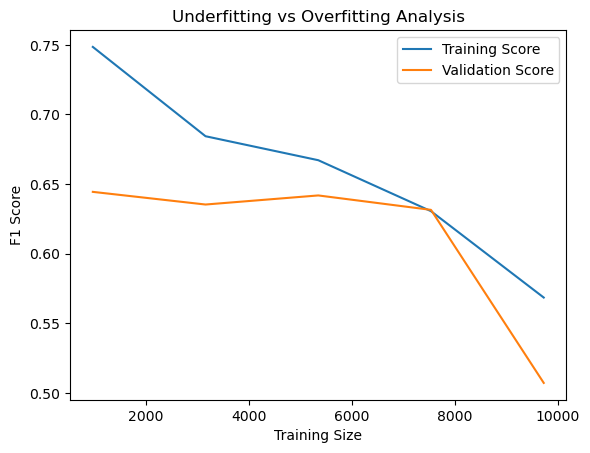

In [22]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    best_dt, X, y, cv=5, scoring="f1"
)

plt.plot(train_sizes, train_scores.mean(axis=1), label="Training Score")
plt.plot(train_sizes, test_scores.mean(axis=1), label="Validation Score")
plt.xlabel("Training Size")
plt.ylabel("F1 Score")
plt.title("Underfitting vs Overfitting Analysis")
plt.legend()
plt.show()


### Underfitting and Overfitting Analysis

Underfitting occurs when a model is too simple to capture underlying patterns, resulting in poor performance on both training and test data.

Overfitting occurs when a model is too complex and performs well on training data but poorly on unseen data.

The learning curve shows that the tuned Decision Tree reduces the gap between training and validation performance, indicating improved generalization and controlled model complexity.


Final Model Selection

Based on the comparison of accuracy, precision, recall, and F1-score, the Tuned Logistic Regression model demonstrates the best overall performance.  
Although the performance improvement after tuning is marginal, the tuned model maintains the highest accuracy and F1-score while remaining simple and interpretable.

Therefore, the Tuned Logistic Regression model is selected as the final model for deployment in the user interface.

tuned logistic regression is called as best_model.pkl


In [23]:
import joblib

# Save final trained model
joblib.dump(best_lr, "best_model.pkl")

# Save feature list (VERY IMPORTANT for UI)
joblib.dump(features, "model_columns.pkl")

print("Model saved as best_model.pkl")
print("Feature list saved as model_columns.pkl")


Model saved as best_model.pkl
Feature list saved as model_columns.pkl


Model Saving

The final tuned Logistic Regression model was saved using the `joblib` library.  
Saving the trained model allows it to be reused for deployment in the user interface without retraining.
